In [ ]:
# Clone the KoVAE repository
!git clone https://github.com/LeoneFabio/KoVAE.git

In [2]:
%cd KoVAE

[Errno 2] No such file or directory: 'KoVAE'
/home/dauin_user/fleone/KoVAE


In [1]:
# Install system dependencies
!apt-get update
!apt-get install -y ffmpeg bzip2 libomp-dev

Reading package lists... Done
E: List directory /var/lib/apt/lists/partial is missing. - Acquire (13: Permission denied)
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [2]:
# The repository requires a specific version of PyTorch with CUDA support (CUDA 11.7)
# Install PyTorch with CUDA support (CUDA 11.7)
!pip install torch==2.0.0+cu117 torchvision==0.15.0+cu117 torchaudio==2.0.0+cu117 -f https://download.pytorch.org/whl/torch_stable.html


Looking in links: https://download.pytorch.org/whl/torch_stable.html
  Using cached https://download.pytorch.org/whl/cu117/torch-2.0.0%2Bcu117-cp39-cp39-linux_x86_64.whl (1843.9 MB)
  Using cached https://download.pytorch.org/whl/cu117/torchvision-0.15.0%2Bcu117-cp39-cp39-linux_x86_64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu117/torchaudio-2.0.0%2Bcu117-cp39-cp39-linux_x86_64.whl (4.4 MB)
  Using cached filelock-3.18.0-py3-none-any.whl (16 kB)
  Using cached triton-2.0.0-1-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (63.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.7/29.7 MB 21.6 MB/s eta 0:00:0000:0100:01
  Using cached lit-18.1.8-py3-none-any.whl (96 kB)


In [3]:
# Install necessary Python packages
!pip install absl-py==1.4.0 boto3==1.26.149 pandas==2.0.2 scikit-learn==1.2.2
!pip install tensorflow==2.12.0 tensorboard==2.12.2
!pip install hyperopt==0.2.7 joblib==1.2.0 matplotlib==3.7.1
!pip install nvidia-cublas-cu11==11.11.3.6 nvidia-cudnn-cu11==8.6.0.163
!pip install torchdiffeq==0.2.3
!pip install neptune-client

  Using cached absl_py-1.4.0-py3-none-any.whl (126 kB)
  Using cached boto3-1.26.149-py3-none-any.whl (135 kB)
  Using cached pandas-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)
  Using cached scikit_learn-1.2.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
  Using cached jmespath-1.0.1-py3-none-any.whl (20 kB)
  Using cached botocore-1.29.165-py3-none-any.whl (11.0 MB)
  Using cached s3transfer-0.6.2-py3-none-any.whl (79 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.2
    Uninstalling scikit-learn-1.1.2:
      Successfully uninstalled scikit-learn-1.1.2
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.0
    Uninstalling pandas-1.5.0:
      Successfully uninstalled pandas-1.5.0
  Using cached tensorflow-2.12.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (585.9 MB)
  Using cached tensorboard-2.12.2-

In [23]:
# Run - Generation of synthetic data

#!python run_regular.py --dataset sine --w_kl .009 --w_pred_prior .03 --epochs 1

#!python run_irregular.py --dataset stock --w_rec 1. --w_kl .009 --w_pred_prior .03 --missing_value 0.3 --inp_dim 6 --epochs 1

#!python run_regular.py --dataset stock --w_rec 1. --w_kl .009 --w_pred_prior .03 --epochs 300



#EV DATASET

#!python run_regular.py --dataset EV --w_kl .009 --w_pred_prior .03 --epochs 1


!python run_irregular.py --dataset EV --w_rec 1. --w_kl .009 --w_pred_prior .03 --missing_value 0.3 --inp_dim 7 --epochs 800 --event trip

2025-08-12 13:11:15.115948: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-12 13:11:16.340884: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
[neptune] [warning] /opt/conda/lib/python3.9/site-packages/neptune/internal/backends/hosted_client.py:51: NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] /home/dauin_user/fleone/KoVAE/run_irregular.py:5: NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import direct

In [22]:
##################### TO RUN ONLY AFTER A WRONG EXECUTION OF THE PREVIOUS CELL ################
!rm -rf datasets/EV0.3/ datasets/stock0.3/ Generated_data/ Output_info/ visualizations/

In [24]:
# Visualize dataset features

import json

with open ('Output_info/EV_features.json', 'r') as f:
    features = json.load(f)
print(features)

['odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode', 'duration_minutes']


In [26]:
# Visualize sample of Generated Data

import torch
# Load the tensor
generated_data = torch.load('Generated_data/EV_generated_data.pt')

# Check shape or values
print(generated_data.shape)
print(generated_data[:2])  # Print first 2 samples

torch.Size([489, 24, 7])
tensor([[[1.0491e+04, 1.0534e+04, 9.4480e+01, 8.4912e+01, 5.1409e-11,
          6.1322e-11, 1.0250e+02],
         [1.0497e+04, 1.0640e+04, 9.1952e+01, 8.1976e+01, 3.1988e-11,
          3.7265e-11, 6.0858e+01],
         [1.0599e+04, 1.0733e+04, 9.0325e+01, 8.0530e+01, 2.9946e-11,
          3.3817e-11, 5.4533e+01],
         [1.0658e+04, 1.0787e+04, 8.9901e+01, 8.0145e+01, 2.9281e-11,
          3.2561e-11, 5.2936e+01],
         [1.0705e+04, 1.0833e+04, 8.9631e+01, 7.9909e+01, 2.9136e-11,
          3.2026e-11, 5.2429e+01],
         [1.0739e+04, 1.0868e+04, 8.9257e+01, 7.9589e+01, 2.9179e-11,
          3.1741e-11, 5.1848e+01],
         [1.0768e+04, 1.0900e+04, 8.9266e+01, 7.9590e+01, 2.9297e-11,
          3.1614e-11, 5.2124e+01],
         [1.0798e+04, 1.0932e+04, 8.9315e+01, 7.9640e+01, 2.9473e-11,
          3.1572e-11, 5.2558e+01],
         [1.0825e+04, 1.0962e+04, 8.9350e+01, 7.9697e+01, 2.9678e-11,
          3.1574e-11, 5.2944e+01],
         [1.0850e+04, 1.0988e+

In [65]:
import pandas as pd

trip_data = pd.read_csv('./Data_saved/EV_generated_data_only_trip.csv')

# Remove duplicates
trip_data = trip_data.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data)}")

trip_data['km_driven'] = trip_data['end_odo'] - trip_data['odo']
trip_data['discharge'] = trip_data['soc'] - trip_data['end_soc']

print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())


Number of rows after removing duplicates: 25
📊 Statistics on driven km:
 count     25.000000
mean     103.713790
std       71.706268
min     -120.893236
25%      112.783280
50%      131.957046
75%      137.932009
max      143.317142
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    25.000000
mean      9.022043
std       1.039558
min       6.237359
25%       8.893704
50%       9.435609
75%       9.667219
max       9.975832
Name: discharge, dtype: float64


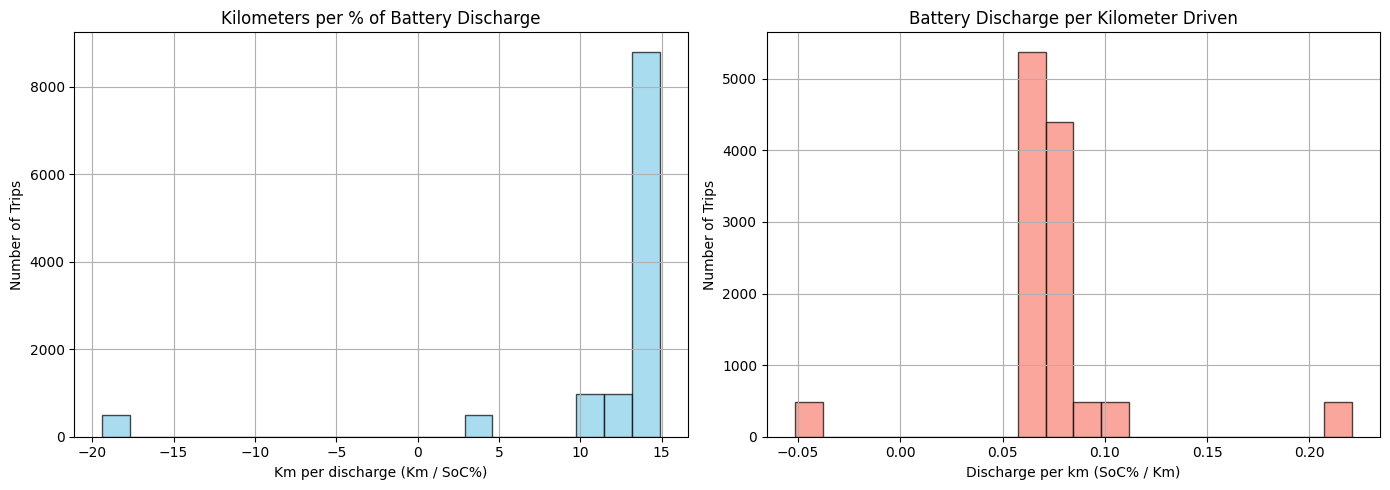

In [57]:
import matplotlib.pyplot as plt

trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

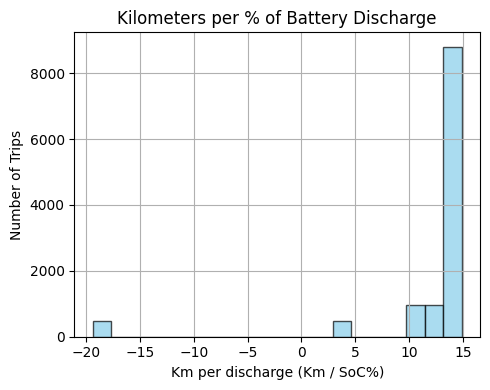

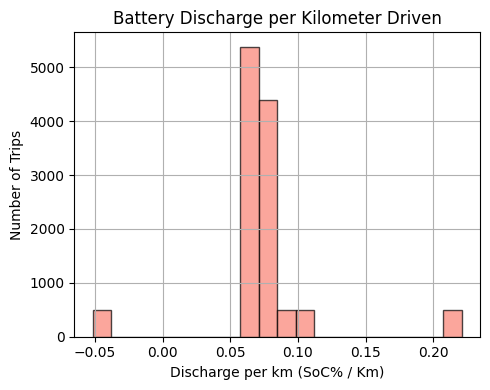

In [58]:
# Number of plots
n_models = 1  # only one dataset
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

# First histogram
ax = axes[0, 0]
ax.hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Kilometers per % of Battery Discharge')
ax.set_xlabel('Km per discharge (Km / SoC%)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()

# Second histogram
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

ax = axes[0, 0]
ax.hist(
    trip_data['discharge_per_km'],
    bins=20,
    color='salmon',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Battery Discharge per Kilometer Driven')
ax.set_xlabel('Discharge per km (SoC% / Km)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()


In [59]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Row with maximum Km/SoC driven:\n")
max_km_row.head()


 Row with maximum Km/SoC driven:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
14,10967.60863,11105.540639,89.473393,80.199765,3.143714e-11,3.231135e-11,53.914543,137.932009,9.273628,14.873576,0.067233
38,10967.60863,11105.540639,89.473393,80.199765,3.143714e-11,3.231135e-11,53.914543,137.932009,9.273628,14.873576,0.067233
62,10967.60863,11105.540639,89.473393,80.199765,3.143714e-11,3.231135e-11,53.914543,137.932009,9.273628,14.873576,0.067233
86,10967.60863,11105.540639,89.473393,80.199765,3.143714e-11,3.231135e-11,53.914543,137.932009,9.273628,14.873576,0.067233
110,10967.60863,11105.540639,89.473393,80.199765,3.143714e-11,3.231135e-11,53.914543,137.932009,9.273628,14.873576,0.067233


In [60]:
outliers = trip_data[trip_data['km_per_perc_of_battery'] > 20].sort_values(by='km_per_perc_of_battery', ascending=False)
print(f'There are {len(outliers)} outliers')

There are 0 outliers


In [42]:
pip install --upgrade seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.0
    Uninstalling seaborn-0.12.0:
      Successfully uninstalled seaborn-0.12.0
Note: you may need to restart the kernel to use updated packages.


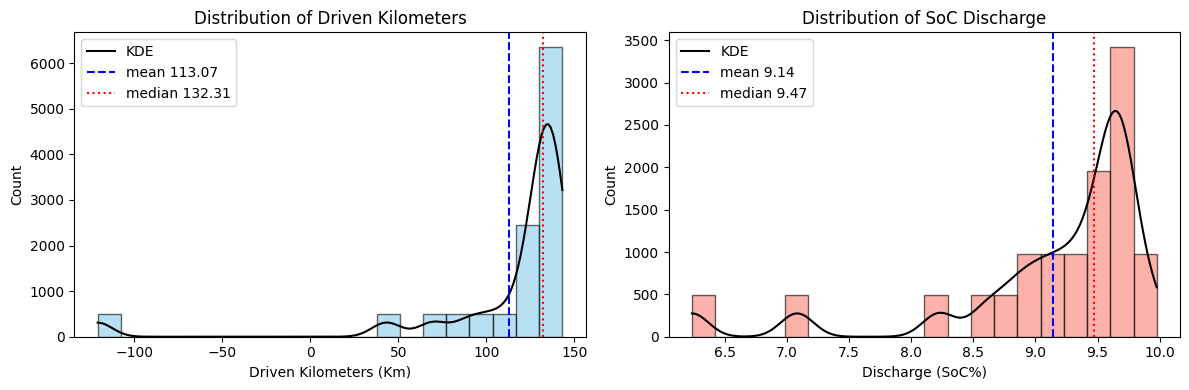

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

# Usage example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()


In [51]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 29.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.5/389.5 kB 4.5 MB/s eta 0:00:0000:01


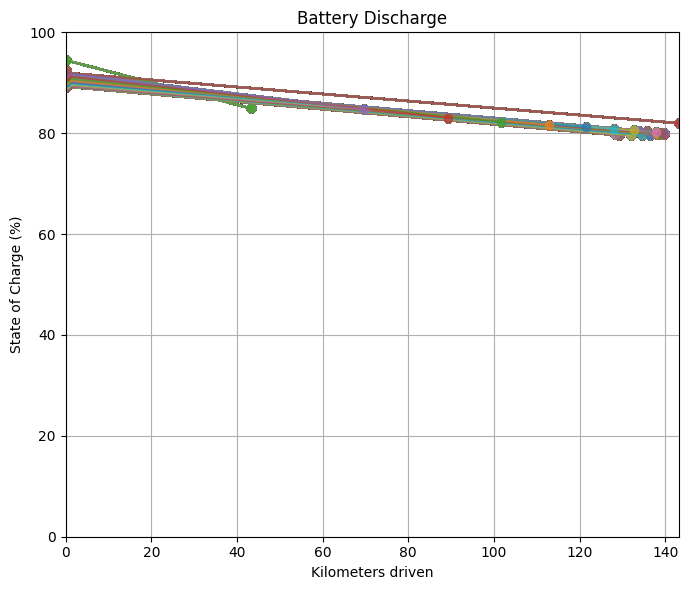

In [63]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()
